# 08.1 Setup & data
# 08.2 Define R target / regime
# 08.3 Baseline modeling (predict R)
# 08.4 SHAP for R (谁影响R)
# 08.5 R_regime analysis（最重要）
# 08.6 Simple rules（设计指导）

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../data/processed/hydrovoltaic_dataset_phase2_input_utf8.csv",
    encoding="utf-8-sig"
)

In [3]:
# Define Model A and Model B features
# Model A = mechanistic baseline
# Model B = Model A + internal resistance
FEATURES_MODEL_A = [
    "material_class",
    "structure_class",
    "built_in_asymmetry",
    "inorganic_electrolyte_present",
    "polyelectrolyte_present",
    "has_anionic",
    "has_cationic",
    "has_zwitterionic",
    "mechanism_simple",
    "water_interaction_mode",
    "top_electrode",
    "bottom_electrode",
    "electrode_symmetry",
    "metal_electrode",
    "ionic_groups",
    "ion_type"
]

FEATURES_MODEL_B = FEATURES_MODEL_A + [
    "log_internal_resistance_Mohm",
    "has_internal_resistance"
]

print("Model A features:", len(FEATURES_MODEL_A))
print("Model B features:", len(FEATURES_MODEL_B))

Model A features: 16
Model B features: 18


In [4]:
# 定义 target（核心变化）
TARGET_R = "log_internal_resistance_Mohm"

FEATURES = FEATURES_MODEL_A   # ❗不用Model B（去掉R本身）

df_r = df.dropna(subset=[TARGET_R]).copy()

X = df_r[FEATURES]
y = df_r[TARGET_R]

In [5]:
# baseline modeling（看看R能不能被预测）
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor

def build_preprocessor(df_input, features):
    numeric_features = []
    categorical_features = []

    for col in features:
        if pd.api.types.is_numeric_dtype(df_input[col]):
            numeric_features.append(col)
        else:
            categorical_features.append(col)

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )

    return preprocessor


rf_R_model = Pipeline([
    ("preprocessor", build_preprocessor(df_r, FEATURES)),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

cv = ShuffleSplit(
    n_splits=50,
    test_size=0.2,
    random_state=42
)

scores = cross_val_score(
    rf_R_model,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("R prediction CV R2:")
print("mean:", scores.mean())
print("std:", scores.std())
print("min:", scores.min())
print("max:", scores.max())

R prediction CV R2:
mean: 0.1511976950670249
std: 0.20139801783887354
min: -0.42018442660305255
max: 0.5171408442136141


In [6]:
rf_R_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

The resistance model achieves modest predictive performance (mean CV R² ≈ 0.15), indicating that internal resistance is partially encoded in the available design descriptors but cannot be fully explained by them. This suggests that resistance is an emergent system-level property influenced by structure, ion transport, electrodes, geometry, and unreported experimental conditions.

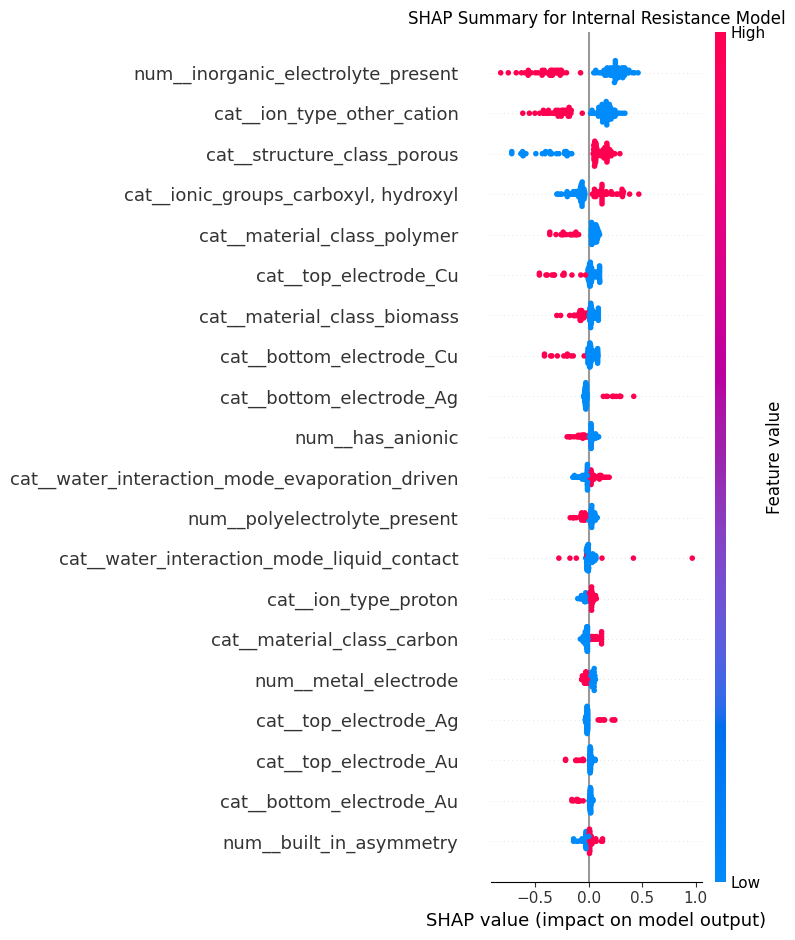

In [7]:
# Extract fitted preprocessor and model
preprocessor_R = rf_R_model.named_steps["preprocessor"]
model_R = rf_R_model.named_steps["model"]

# Transform X
X_R_processed = preprocessor_R.transform(X)
feature_names_R = preprocessor_R.get_feature_names_out()

# SHAP for R model
import shap

explainer_R = shap.TreeExplainer(model_R)
shap_values_R = explainer_R.shap_values(X_R_processed)

shap.summary_plot(
    shap_values_R,
    X_R_processed,
    feature_names=feature_names_R,
    show=False
)

plt.title("SHAP Summary for Internal Resistance Model")
plt.tight_layout()
plt.show()

### SHAP Analysis of Internal Resistance

Feature importance analysis reveals that internal resistance is primarily controlled by transport-related descriptors rather than nominal mechanism classification.

The presence of inorganic electrolytes is the most influential factor, consistently reducing internal resistance, reflecting enhanced ionic conductivity. Ion type also plays a significant role, with non-proton cations generally associated with lower resistance compared to proton-based systems.

Structural effects are also evident: porous architectures tend to increase internal resistance, likely due to increased tortuosity and longer ion transport pathways. In contrast, the presence of surface functional groups (e.g., carboxyl, hydroxyl) contributes to lower resistance, possibly by facilitating ion transport through surface charge effects.

Electrode materials show secondary influence, while mechanism labels contribute minimally, indicating that literature-reported mechanisms do not correspond to well-defined transport regimes.

Overall, internal resistance is governed by a combination of electrolyte availability, ion transport properties, and structural features, supporting its role as a physically meaningful, system-level descriptor.

In [8]:
# Define R regime
# Define resistance regime using PDP-derived threshold
R_threshold = -1.0

df_r["R_regime"] = np.where(
    df_r[TARGET_R] < R_threshold,
    "low_R",
    "high_R"
)

df_r["R_regime"].value_counts()

R_regime
high_R    66
low_R     46
Name: count, dtype: int64

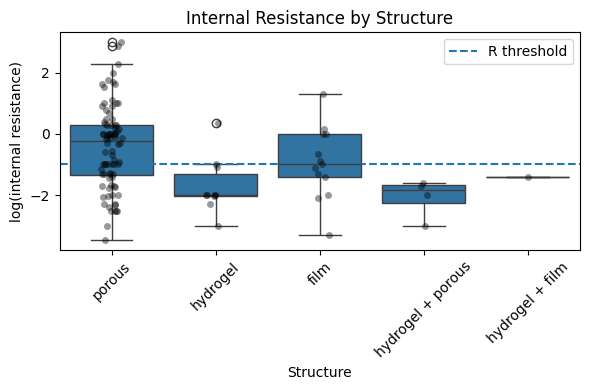

In [9]:
# Internal resistance by structure
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_r,
    x="structure_class",
    y=TARGET_R
)

sns.stripplot(
    data=df_r,
    x="structure_class",
    y=TARGET_R,
    color="black",
    alpha=0.4
)

plt.axhline(R_threshold, linestyle="--", label="R threshold")

plt.xticks(rotation=45)
plt.title("Internal Resistance by Structure")
plt.xlabel("Structure")
plt.ylabel("log(internal resistance)")
plt.legend()

plt.tight_layout()
plt.show()

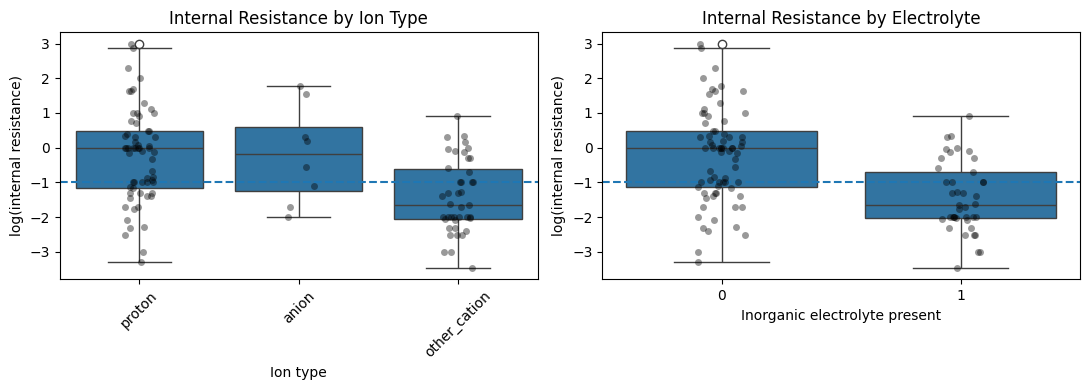

In [10]:
# Internal resistance by ion type and electrolyte
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(
    data=df_r,
    x="ion_type",
    y=TARGET_R,
    ax=axes[0]
)

sns.stripplot(
    data=df_r,
    x="ion_type",
    y=TARGET_R,
    color="black",
    alpha=0.4,
    ax=axes[0]
)

axes[0].axhline(R_threshold, linestyle="--")
axes[0].set_title("Internal Resistance by Ion Type")
axes[0].set_xlabel("Ion type")
axes[0].set_ylabel("log(internal resistance)")
axes[0].tick_params(axis="x", rotation=45)


sns.boxplot(
    data=df_r,
    x="inorganic_electrolyte_present",
    y=TARGET_R,
    ax=axes[1]
)

sns.stripplot(
    data=df_r,
    x="inorganic_electrolyte_present",
    y=TARGET_R,
    color="black",
    alpha=0.4,
    ax=axes[1]
)

axes[1].axhline(R_threshold, linestyle="--")
axes[1].set_title("Internal Resistance by Electrolyte")
axes[1].set_xlabel("Inorganic electrolyte present")
axes[1].set_ylabel("log(internal resistance)")

plt.tight_layout()
plt.show()

While substantial overlap exists between categories, clear shifts in the distribution of internal resistance are observed. 

For example, the presence of inorganic electrolytes consistently shifts the resistance distribution toward lower values, indicating a systematic reduction in internal resistance. Similarly, non-proton cation systems exhibit a tendency toward lower resistance compared to proton-based systems.

These trends suggest that although no single descriptor fully determines internal resistance, several design factors exert consistent directional influence on transport properties.

In [11]:
# Mann–Whitney U test（非参数）
from scipy.stats import mannwhitneyu

group0 = df_r[df_r["inorganic_electrolyte_present"] == 0][TARGET_R]
group1 = df_r[df_r["inorganic_electrolyte_present"] == 1][TARGET_R]

stat, p = mannwhitneyu(group0, group1)

print("p-value:", p)

p-value: 4.104276502713196e-06


The presence of inorganic electrolytes leads to a clear and statistically significant reduction in internal resistance. 

This effect is consistently observed across multiple analyses: SHAP results identify electrolyte presence as the most influential feature reducing resistance, while direct distribution analysis shows a systematic shift toward lower resistance values. 

A non-parametric Mann–Whitney U test confirms that the two groups differ significantly (p ≈ 4 × 10⁻⁶), indicating that the observed reduction is unlikely to arise from random variation.

These results demonstrate that electrolyte availability is a primary factor governing ion transport and internal resistance in hydrovoltaic systems.

In [12]:
group0 = df_r[df_r["structure_class"] == "porous"][TARGET_R]
group1 = df_r[df_r["structure_class"] != "porous"][TARGET_R]

stat, p = mannwhitneyu(group0, group1)
print(p)

0.0013696698959293192


In [13]:
group0 = df_r[df_r["ion_type"] == "proton"][TARGET_R]
group1 = df_r[df_r["ion_type"] == "other_cation"][TARGET_R]

stat, p = mannwhitneyu(group0, group1)
print(p)

1.0849891656582801e-05


### Statistical Evidence for Factors Governing Internal Resistance

To quantitatively evaluate the influence of key design descriptors on internal resistance, non-parametric Mann–Whitney U tests were performed across major feature groups.

The presence of inorganic electrolytes shows a highly significant effect (p ≈ 4 × 10⁻⁶), with electrolyte-containing systems consistently exhibiting lower resistance. This confirms that enhanced ionic conductivity is a dominant factor in reducing internal resistance.

Structural effects are also statistically significant (p ≈ 1 × 10⁻³). Porous architectures tend to exhibit higher resistance compared to non-porous systems, reflecting increased tortuosity and longer ion transport pathways.

Ion type further contributes significantly (p ≈ 1 × 10⁻⁵), with non-proton cation systems generally displaying lower resistance than proton-based systems. This highlights the role of ion mobility and transport mechanisms beyond proton conduction.

Despite overlap between distributions, these results demonstrate consistent and statistically significant shifts in resistance, indicating that these factors systematically influence transport behavior rather than acting as deterministic rules.

Together, these findings establish that internal resistance is governed by a combination of electrolyte availability, ion transport properties, and structural features, rather than nominal mechanism classification.

Specific cation-level trends were not emphasized because the available data were insufficiently balanced across ion species.

Although ion type shows a statistically significant effect at a coarse level (proton vs. non-proton), no consistent ranking can be established among specific cations (e.g., Li⁺, K⁺, Ca²⁺). 

High-performance and low-resistance cases are observed across multiple ion species, indicating that ion identity alone does not determine transport efficiency. Instead, the overall transport environment—including structure, electrolyte concentration, and interfacial properties—plays a more dominant role.

## 08.7 Cation-Level Analysis (Non-proton Systems)

In [14]:
# 数据准备（用你现有 df_r）
# focus on non-proton systems
df_cation = df_r[df_r["ion_type"] != "proton"].copy()

# remove missing
df_cation = df_cation.dropna(subset=["primary_mobile_ion", TARGET_R])

# check counts
cation_counts = df_cation["primary_mobile_ion"].value_counts()
print(cation_counts)

primary_mobile_ion
Na+     22
Li+      9
Ca2+     6
OH-      5
Cl-      3
K+       2
Fe3+     2
MA+      1
Name: count, dtype: int64


In [15]:
# 样本数筛选（关键）
# keep ions with sufficient samples
valid_ions = cation_counts[cation_counts >= 5].index

df_cation_filtered = df_cation[
    df_cation["primary_mobile_ion"].isin(valid_ions)
]

print(df_cation_filtered["primary_mobile_ion"].value_counts())

primary_mobile_ion
Na+     22
Li+      9
Ca2+     6
OH-      5
Name: count, dtype: int64


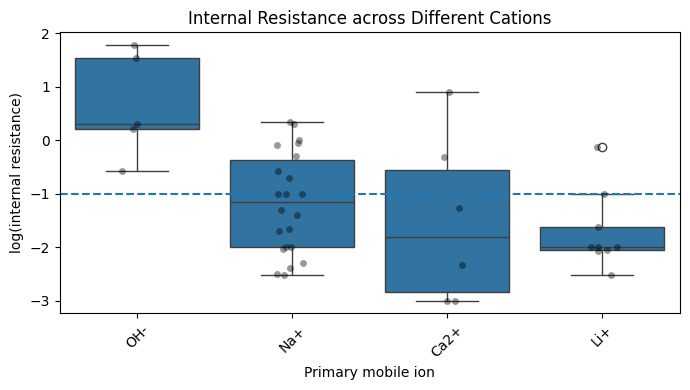

In [16]:
# boxplot（R，不是performance）
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df_cation_filtered,
    x="primary_mobile_ion",
    y=TARGET_R
)

sns.stripplot(
    data=df_cation_filtered,
    x="primary_mobile_ion",
    y=TARGET_R,
    color="black",
    alpha=0.4
)

plt.axhline(R_threshold, linestyle="--")

plt.title("Internal Resistance across Different Cations")
plt.xlabel("Primary mobile ion")
plt.ylabel("log(internal resistance)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# Kruskal-Wallis（核心）
from scipy.stats import kruskal

groups = [
    group[TARGET_R].values
    for name, group in df_cation_filtered.groupby("primary_mobile_ion")
]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"p-value: {p_value:.4e}")

Kruskal-Wallis H-statistic: 11.0369
p-value: 1.1528e-02


In [18]:
# （推荐）：post-hoc（Games-Howell）
import pingouin as pg

posthoc = pg.pairwise_gameshowell(
    data=df_cation_filtered,
    dv=TARGET_R,
    between="primary_mobile_ion"
)

posthoc

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Ca2+,Li+,-1.501723,-1.711059,0.209335,0.687149,0.304643,6.417978,0.989265,0.174361
1,Ca2+,Na+,-1.501723,-1.177566,-0.324157,0.674428,-0.480640,6.014792,0.960653,-0.287334
2,Ca2+,OH-,-1.501723,0.649447,-2.151171,0.779401,-2.760032,8.453399,0.089849,-1.461824
3,Li+,Na+,-1.711059,-1.177566,-0.533492,0.313930,-1.699398,19.497783,0.350615,-0.584238
4,Li+,OH-,-1.711059,0.649447,-2.360506,0.501164,-4.710049,6.467566,0.010926,-2.700414
5,Na+,OH-,-1.177566,0.649447,-1.827014,0.483574,-3.778145,5.809395,0.036642,-1.862153


### Role of Ion Identity in Determining Internal Resistance

To further examine the influence of ion identity beyond the proton vs. non-proton distinction, statistical comparisons were performed among the most frequently occurring cations.

As shown in Figure X, substantial overlap in internal resistance is observed across different ions, despite visible differences in their distributions. A Kruskal–Wallis test indicates a statistically significant difference among groups (p = 1.15 × 10⁻²). However, the distributions are highly heterogeneous, with large intra-group variance and overlapping ranges across most cations.

Notably, while certain ions (e.g., OH⁻) exhibit higher resistance values, no consistent or monotonic ranking can be established among the remaining cations (e.g., Na⁺, Ca²⁺, Li⁺). This suggests that the observed differences are system-dependent rather than intrinsic to ion identity.

Overall, these results indicate that ion identity alone is not a reliable predictor of internal resistance, especially when compared to system-level factors such as electrolyte presence and structural characteristics.